# PIAB2D — Two-dimensional particle in a rectangular box

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>

## Question

How do two independent hard-wall directions produce product states and degeneracy?

## Learning objectives

- Construct normalized product eigenstates in a rectangle.
- Build the sparse 2D kinetic matrix and solve for low eigenpairs.
- Compare square-box and generic rectangular degeneracies.
- Check matrix eigenvalues, eigenvectors, boundaries, and normalization.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This extends PIAB1D by separation of variables in a second Cartesian direction.


## Model and analytical solution

For $0<x<L_x$ and $0<y<L_y$, homogeneous Dirichlet conditions apply on every
edge. In reduced units,

$$
\psi_{n_xn_y}(x,y)=\frac{2}{\sqrt{L_xL_y}}
\sin\!\left(\frac{n_x\pi x}{L_x}\right)
\sin\!\left(\frac{n_y\pi y}{L_y}\right),
$$

$$
E_{n_xn_y}=\pi^2\left(\frac{n_x^2}{L_x^2}+\frac{n_y^2}{L_y^2}\right).
$$


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from scipy import sparse
from scipy.sparse.linalg import eigsh
np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
Lx, Ly = 1.0, 1.0
x = np.linspace(0.0, Lx, 161)
y = np.linspace(0.0, Ly, 161)
X, Y = np.meshgrid(x, y, indexing="ij")


def psi2(nx, ny, X_values=X, Y_values=Y, lx=Lx, ly=Ly):
    prefactor = 2.0 / np.sqrt(lx * ly)
    return prefactor * np.sin(nx * np.pi * X_values / lx) * np.sin(ny * np.pi * Y_values / ly)


nx, ny = 2, 3
state = psi2(nx, ny)
energy = np.pi**2 * ((nx / Lx) ** 2 + (ny / Ly) ** 2)
assert state.shape == (len(x), len(y))
assert np.issubdtype(state.dtype, np.floating)
norm = np.trapezoid(np.trapezoid(np.abs(state) ** 2, x=y, axis=1), x=x)
assert np.isclose(norm, 1.0, rtol=1e-10, atol=1e-12)
assert np.allclose(state[[0, -1], :], 0.0, atol=1e-12)
assert np.allclose(state[:, [0, -1]], 0.0, atol=1e-12)
print(f"state (nx, ny)=({nx}, {ny}), reduced energy={energy:.6f}, sampled norm={norm:.12f}")
print("state array shape:", state.shape)


state (nx, ny)=(2, 3), reduced energy=128.304857, sampled norm=1.000000000000
state array shape: (161, 161)


## Matrix eigenproblem

On interior grids, the positive kinetic matrix is the sparse Kronecker sum

$$
T_h=T_x\otimes I_y+I_x\otimes T_y.
$$

C-order reshaping keeps the $y$ coordinate fastest. The eigensolver returns
Euclidean-normalized vectors; division by $\sqrt{h_xh_y}$ produces a sampled
quadrature normalization.


In [3]:
interior_shape = (25, 25)
hx, hy = Lx / (interior_shape[0] + 1), Ly / (interior_shape[1] + 1)

def dirichlet_kinetic(count, spacing):
    return sparse.diags(
        (-np.ones(count - 1), 2.0 * np.ones(count), -np.ones(count - 1)),
        offsets=(-1, 0, 1), format="csr"
    ) / spacing**2

Tx = dirichlet_kinetic(interior_shape[0], hx)
Ty = dirichlet_kinetic(interior_shape[1], hy)
Ix = sparse.identity(interior_shape[0], format="csr")
Iy = sparse.identity(interior_shape[1], format="csr")
kinetic_matrix = sparse.kron(Tx, Iy, format="csr") + sparse.kron(Ix, Ty, format="csr")
eigenvalues, eigenvectors = eigsh(
    kinetic_matrix, k=6, which="SA", v0=np.ones(kinetic_matrix.shape[0])
)
order = np.argsort(eigenvalues)
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
energies_x = 4.0 / hx**2 * np.sin(np.arange(1, interior_shape[0] + 1) * np.pi / (2 * (interior_shape[0] + 1))) ** 2
energies_y = 4.0 / hy**2 * np.sin(np.arange(1, interior_shape[1] + 1) * np.pi / (2 * (interior_shape[1] + 1))) ** 2
discrete_reference = np.sort((energies_x[:, None] + energies_y[None, :]).ravel())[:6]
residuals = np.array([
    np.linalg.norm(kinetic_matrix @ eigenvectors[:, index] - value * eigenvectors[:, index])
    / max(1.0, abs(value))
    for index, value in enumerate(eigenvalues)
])
x_interior = np.arange(1, interior_shape[0] + 1) * hx
y_interior = np.arange(1, interior_shape[1] + 1) * hy
Xi, Yi = np.meshgrid(x_interior, y_interior, indexing="ij")
numerical_ground = eigenvectors[:, 0].reshape(interior_shape, order="C") / np.sqrt(hx * hy)
analytical_ground = psi2(1, 1, Xi, Yi)
if np.vdot(numerical_ground, analytical_ground).real < 0.0:
    numerical_ground *= -1.0
assert kinetic_matrix.shape == (np.prod(interior_shape),) * 2
assert np.issubdtype(kinetic_matrix.dtype, np.floating)
assert np.allclose(eigenvalues, discrete_reference, rtol=1e-10, atol=1e-12)
assert np.allclose(numerical_ground, analytical_ground, rtol=1e-10, atol=1e-12)
assert np.max(residuals) < 1e-8
print("kinetic matrix shape, nnz, dtype:", kinetic_matrix.shape, kinetic_matrix.nnz, kinetic_matrix.dtype)
print("lowest matrix eigenvalues:", eigenvalues)
print("eigensolver residual bound satisfied:", np.max(residuals) < 1e-8)


kinetic matrix shape, nnz, dtype: (625, 625) 3025 float64
lowest matrix eigenvalues: [19.715204 49.144265 49.144265 78.573326 97.715642 97.715642]
eigensolver residual bound satisfied: True


## Degeneracy depends on geometry

In a square, swapping $n_x$ and $n_y$ preserves energy. In a generic rectangle,
that symmetry is absent. The following groups low square-box states by their
exact integer value $n_x^2+n_y^2$.


In [4]:
pairs = [(i, j) for i in range(1, 5) for j in range(1, 5)]
groups = {}
for pair in pairs:
    groups.setdefault(pair[0] ** 2 + pair[1] ** 2, []).append(pair)
degenerate = {value: members for value, members in groups.items() if len(members) > 1}
print("square-box degenerate groups:", degenerate)

Lx_rect, Ly_rect = 1.0, 1.3
E23 = np.pi**2 * ((2 / Lx_rect) ** 2 + (3 / Ly_rect) ** 2)
E32 = np.pi**2 * ((3 / Lx_rect) ** 2 + (2 / Ly_rect) ** 2)
assert not np.isclose(E23, E32)
print("rectangular E(2,3), E(3,2):", E23, E32)


square-box degenerate groups: {5: [(1, 2), (2, 1)], 10: [(1, 3), (3, 1)], 17: [(1, 4), (4, 1)], 13: [(2, 3), (3, 2)], 20: [(2, 4), (4, 2)], 25: [(3, 4), (4, 3)]}
rectangular E(2,3), E(3,2): 92.0384410421114 112.18645002658377


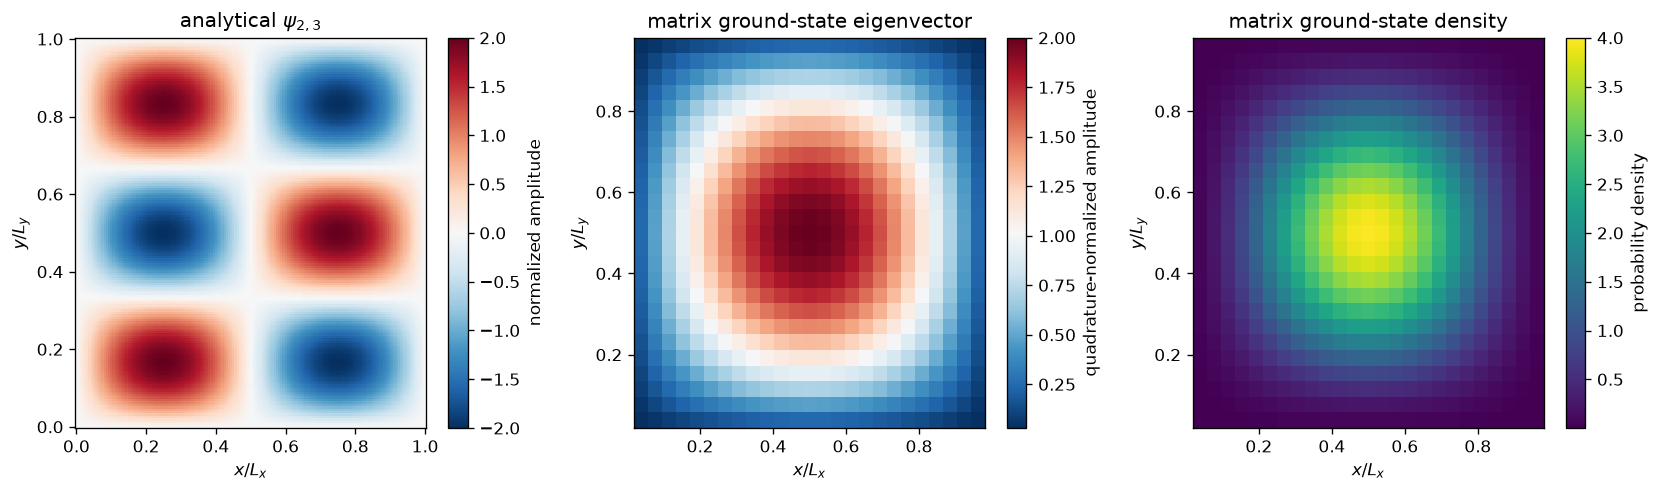

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
image0 = axes[0].pcolormesh(X / Lx, Y / Ly, state, shading="auto", cmap="RdBu_r")
image1 = axes[1].pcolormesh(Xi / Lx, Yi / Ly, numerical_ground, shading="auto", cmap="RdBu_r")
image2 = axes[2].pcolormesh(Xi / Lx, Yi / Ly, np.abs(numerical_ground) ** 2, shading="auto", cmap="viridis")
axes[0].set(title=fr"analytical $\psi_{{{nx},{ny}}}$", xlabel=r"$x/L_x$", ylabel=r"$y/L_y$")
axes[1].set(title="matrix ground-state eigenvector", xlabel=r"$x/L_x$", ylabel=r"$y/L_y$")
axes[2].set(title="matrix ground-state density", xlabel=r"$x/L_x$", ylabel=r"$y/L_y$")
fig.colorbar(image0, ax=axes[0], label="normalized amplitude")
fig.colorbar(image1, ax=axes[1], label="quadrature-normalized amplitude")
fig.colorbar(image2, ax=axes[2], label="probability density")
fig.tight_layout()
show_figure(fig)
plt.close(fig)


## Interpretation and limitations

The sparse matrix is one finite-difference representation of a separable Cartesian rectangle. One grid is not a convergence study, and square-box degeneracy is not a generic material result.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

PIAB3D introduces a third hard-wall direction and cubic versus orthorhombic degeneracy.
